In [1]:
import pandas as pd 
train_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

In [2]:
train_set.describe()

,ID,Distribution_channel,Seniority,Lapse,Payment,Premium,Cost_claims_year,N_claims_history,R_Claims_history,Type_risk,...,N_doors,Weight,Driving_experience_years,Age_Group_16-24,Age_Group_25-39,Age_Group_40-64,Age_Group_65+,Type_fuel_D,Type_fuel_P,N_claims_year
count,62638.000000,62638.000000,62638.000000,62638.000000,62638.000000,62638.000000,62638.000000,62638.000000,62638.000000,62638.0,...,62638.000000,62638.000000,62638.000000,62638.000000,62638.000000,62638.000000,62638.000000,62638.000000,62638.000000,62638.000000
mean,27108.740429,0.464335,6.573166,0.218909,0.348239,333.829036,145.309998,2.576280,0.403813,3.0,...,4.471758,1228.253456,23.952696,0.018040,0.316629,0.567531,0.097800,0.621156,0.378844,0.272949
std,15285.315771,0.498730,6.195634,0.451317,0.476416,137.317849,1757.120107,3.507345,0.660689,0.0,...,0.841470,226.167082,12.388031,0.133098,0.465165,0.495423,0.297046,0.485103,0.485103,0.669435
min,3.000000,0.000000,1.000000,0.000000,0.000000,40.710000,0.000000,0.000000,0.000000,3.0,...,2.000000,246.000000,-3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13951.250000,0.000000,3.000000,0.000000,0.000000,253.570000,0.000000,0.000000,0.000000,3.0,...,4.000000,1070.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27430.000000,0.000000,4.000000,0.000000,0.000000,300.070000,0.000000,1.000000,0.110000,3.0,...,5.000000,1205.000000,23.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,40483.000000,1.000000,9.000000,0.000000,1.000000,370.667500,0.000000,4.000000,0.560000,3.0,...,5.000000,1357.000000,33.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,53500.000000,1.000000,40.000000,6.000000,1.000000,2993.340000,260853.240000,50.000000,26.070000,3.0,...,6.000000,2710.000000,74.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


In [3]:
train_set['Cost_claims_year'].describe()

count     62638.000000
mean        145.309998
std        1757.120107
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      260853.240000
Name: Cost_claims_year, dtype: float64

In [4]:
test_set['Cost_claims_year'].describe()

count    15660.000000
mean       123.300324
std        723.176505
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      25071.950000
Name: Cost_claims_year, dtype: float64

### Check distribution of Cost_claims_year

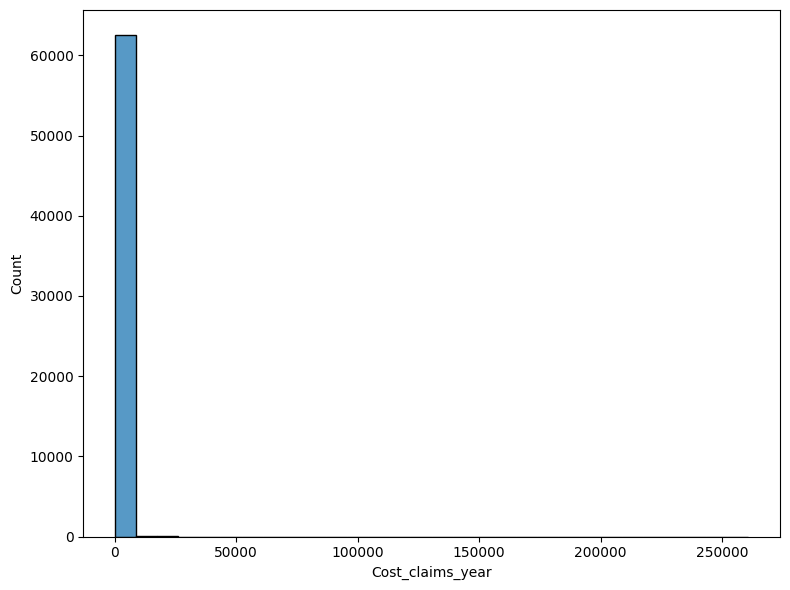

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a single plot for the Test Set Claim_costs histogram
plt.figure(figsize=(8, 6))
sns.histplot(train_set["Cost_claims_year"], bins=30)

plt.tight_layout()
plt.show()


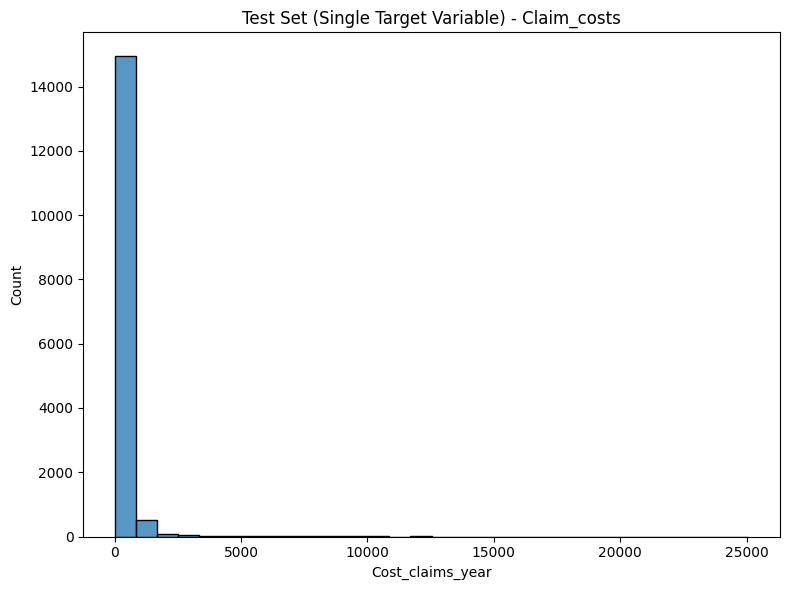

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a single plot for the Test Set Claim_costs histogram
plt.figure(figsize=(8, 6))
sns.histplot(test_set["Cost_claims_year"], bins=30).set_title("Test Set (Single Target Variable) - Claim_costs")

plt.tight_layout()
plt.show()


### applied log transform into target variable since it is highly skewed 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
Train_log = pd.read_csv('train_set.csv')
Test_log = pd.read_csv('test_set.csv')

identifier_column = 'ID'

# Separate features, target, and identifier column
X_train = train_set.drop(columns=['Claim_costs', identifier_column])
y_train = train_set['Claim_costs']
X_test = test_set.drop(columns=['Claim_costs', identifier_column])
y_test = test_set['Claim_costs']

# Standardize only the feature columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames and add the identifier column back
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_train_scaled[identifier_column] = train_set[identifier_column].values

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_test_scaled[identifier_column] = test_set[identifier_column].values

# Recombine the transformed features and target variable
train_set_transformed = X_train_scaled.copy()
train_set_transformed['Claim_costs'] = np.log1p(y_train).reset_index(drop=True)

test_set_transformed = X_test_scaled.copy()
test_set_transformed['Claim_costs'] = np.log1p(y_test).reset_index(drop=True)

# Export the transformed datasets
train_set_transformed.to_csv('train_set_transformed.csv', index=False)
test_set_transformed.to_csv('test_set_transformed.csv', index=False)


In [55]:
train_set_transformed = pd.read_csv('train_set_transformed.csv')
test_set_transformed = pd.read_csv('test_set_transformed.csv')

In [56]:
train_set_transformed[['Claim_costs']].describe()

,Claim_costs
count,10828.000000
mean,5.337649
std,1.277524
min,2.742774
25%,4.223177
50%,5.205187
75%,6.308365
max,11.679656


In [57]:
test_set_transformed[['Claim_costs']].describe()

,Claim_costs
count,2707.000000
mean,5.287710
std,1.242693
min,2.825142
25%,4.221124
50%,5.134739
75%,6.225222
max,10.129545


In [58]:
test_set_transformed[['ID', 'Claim_costs']].head()

,ID,Claim_costs
0,20439,4.373364
1,27015,5.572078
2,37493,4.979007
3,14845,6.783325
4,5029,6.394677


In [59]:
train_set_transformed.info() #62638

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10828 entries, 0 to 10827
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Distribution_channel      10828 non-null  float64
 1   Seniority                 10828 non-null  float64
 2   Lapse                     10828 non-null  float64
 3   Payment                   10828 non-null  float64
 4   Premium                   10828 non-null  float64
 5   N_claims_history          10828 non-null  float64
 6   R_Claims_history          10828 non-null  float64
 7   Type_risk                 10828 non-null  float64
 8   Area                      10828 non-null  float64
 9   Second_driver             10828 non-null  float64
 10  Year_matriculation        10828 non-null  float64
 11  Power                     10828 non-null  float64
 12  Cylinder_capacity         10828 non-null  float64
 13  Value_vehicle             10828 non-null  float64
 14  N_door

In [60]:
test_set_transformed.info() #15660

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2707 entries, 0 to 2706
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Distribution_channel      2707 non-null   float64
 1   Seniority                 2707 non-null   float64
 2   Lapse                     2707 non-null   float64
 3   Payment                   2707 non-null   float64
 4   Premium                   2707 non-null   float64
 5   N_claims_history          2707 non-null   float64
 6   R_Claims_history          2707 non-null   float64
 7   Type_risk                 2707 non-null   float64
 8   Area                      2707 non-null   float64
 9   Second_driver             2707 non-null   float64
 10  Year_matriculation        2707 non-null   float64
 11  Power                     2707 non-null   float64
 12  Cylinder_capacity         2707 non-null   float64
 13  Value_vehicle             2707 non-null   float64
 14  N_doors 

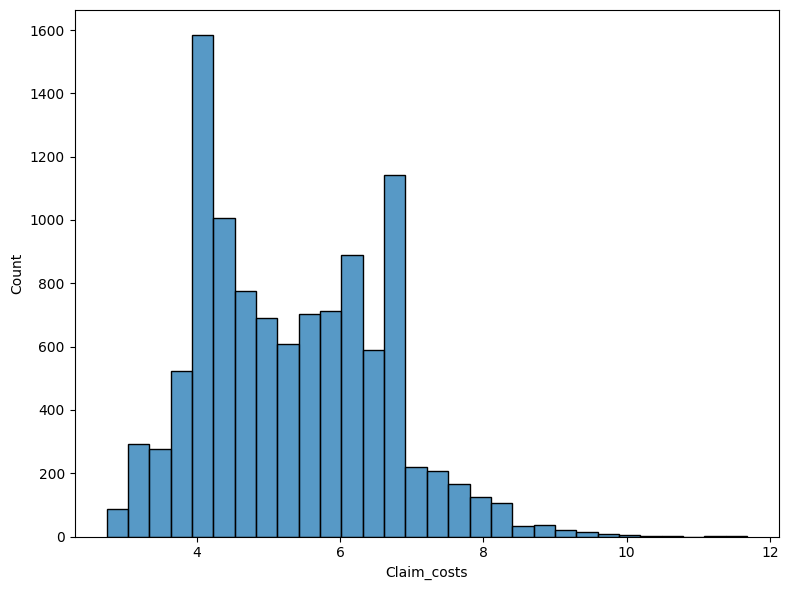

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a single plot for the Test Set Claim_costs histogram
plt.figure(figsize=(8, 6))
sns.histplot(train_set_transformed["Claim_costs"], bins=30)

plt.tight_layout()
plt.show()


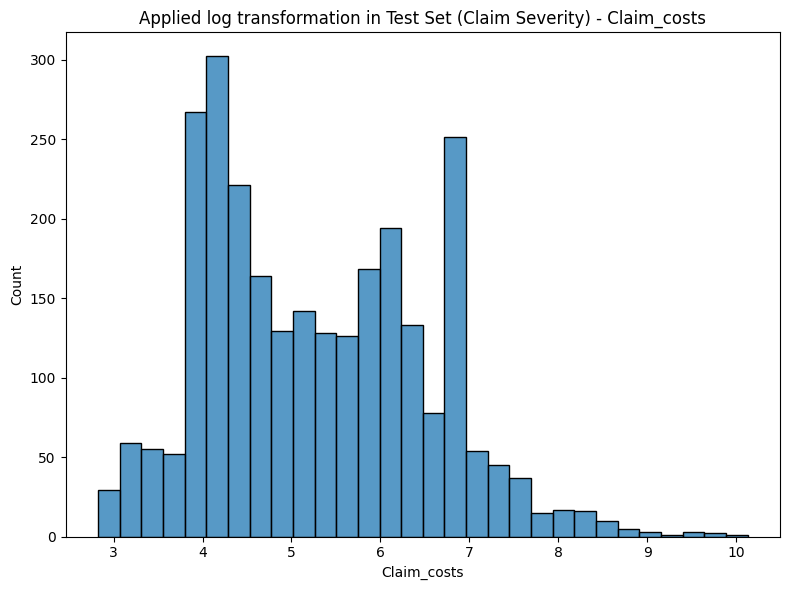

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a single plot for the Test Set Claim_costs histogram
plt.figure(figsize=(8, 6))
sns.histplot(test_set_transformed["Claim_costs"], bins=30).set_title("Applied log transformation in Test Set (Claim Severity) - Claim_costs")

plt.tight_layout()
plt.show()
